In [1]:
from numpy import array, isnan, sqrt
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import numpy as np

def find_breakpoint(x, y, dy):
    """Find the breakpoint xb in a piecewise linear model with a single breakpoint.
    Inputs:
    x: array of x values
    y: array of y values
    dy: array of uncertainties in y values

    Returns:
    'xb': estimated breakpoint
    'beta0': estimated intercept before the breakpoint
    'beta1': estimated slope after the breakpoint
    'error': estimated uncertainty in xb
    'chi2': chi-squared of the fit at the optimal breakpoint"""
    
    dy2 = dy * dy
    
    b1 = (y/dy2).sum()
    m11 = (1./dy2).sum()
    par = np.array([0., 0., np.nan])  # [beta0, beta1, error]

    def break_fun(xb):
        """
        Function to find the breakpoint xb; returns chi^2(xb).
        The xb uncertainty is stored in par[2] and is estimated from the Hessian matrix.

        PIECEWISE MODEL CHI-SQUARED:
        xᵢ < xb:  yᵢ = β₀
        xᵢ ≥ xb:  yᵢ = β₀ + β₁(xᵢ - xb)
        
        χ²(xb, β₀, β₁) = Σ_{xᵢ<xb} (yᵢ - β₀)²/σᵢ² + Σ_{xᵢ≥xb} [yᵢ - β₀ - β₁(xᵢ-xb)]²/σᵢ²
        
        For fixed xb, optimal β₀ and β₁ are found analytically via weighted least squares.
        """

        if isnan(xb):
            xb = x.min()
        
        xl = x < xb
        xr = ~xl
        
        m12 = ((x[xr] - xb) / dy2[xr]).sum()
        m22 = ((x[xr] - xb)**2 / dy2[xr]).sum()
        det2 = m11 * m22 - m12**2
        b2 = (y[xr] * (x[xr] - xb) / dy2[xr]).sum()
        
        if det2 > 0:
            par[0] = (m22*b1 - m12*b2) / det2
            par[1] = (m11*b2 - m12*b1) / det2
        
        #  xb uncertainty from the Hessian matrix
        if xl.sum() > 0:
            chi0 = ((y[xl] - par[0])**2 / dy2[xl]).sum()
            m01 = -par[1] * (1./dy2[xr]).sum()
            m00 = -par[1] * m01
            m02 = ((y[xr] - par[0]) / dy2[xr]).sum() - 2.*par[1]*m12
            # Schur complement for inverse-matrix element
            par[2] = 1./sqrt(m00 + (m01*(m02*m12 - m01*m22) + m02*(m01*m12 - m02*m11))/det2)
        else:
            chi0 = 0.
        
        # Return chi^2(xb)
        return chi0 + ((y[xr] - par[1]*(x[xr] - xb) - par[0])**2 / dy2[xr]).sum()
    
    # (6) Minimize chi^2 with respect to xb
    res = minimize_scalar(break_fun, bounds=(x.min(), x.max()-1.e-5), method='bounded')
    chi2, xb = res['fun'], res['x']
    
    return {
        'error': par[2],
        'chi2': chi2,
        'beta0': par[0],
        'beta1': par[1],
        'xb': xb}


In [2]:
np.random.seed(42)

# Параметры модели
xb_true = 50.0      # Истинная точка излома
beta0_true = 100.0  # Истинный уровень до излома
beta1_true = 2.5    # Истинный наклон после излома
sigma_noise = 5.0   # СКО шума

# Создаём X координаты
x = np.linspace(0, 100, 40)

# Создаём Y по кусочной модели с шумом
y = np.zeros_like(x, dtype=float)
mask = x < xb_true
y[mask] = beta0_true
y[~mask] = beta0_true + beta1_true * (x[~mask] - xb_true)
y += np.random.normal(0, sigma_noise, size=y.shape)

# Ошибки данных
dy = np.ones_like(x) * sigma_noise

# Запускаем функцию поиска точки излома
results = find_breakpoint(x, y, dy)

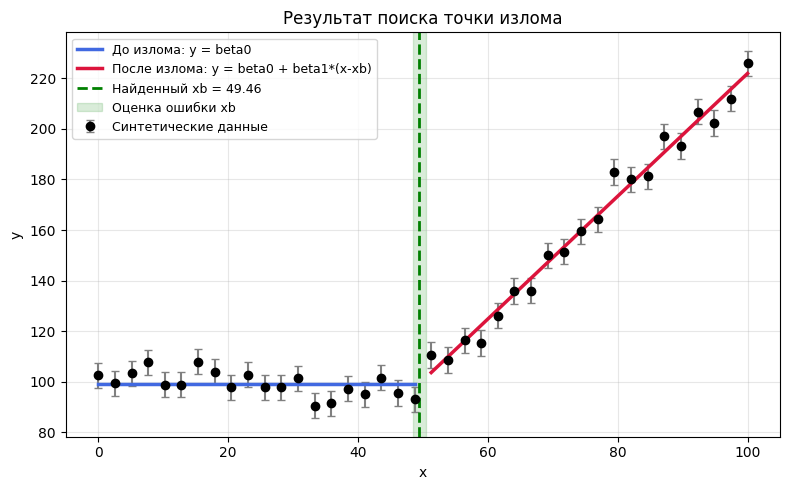

In [3]:

fig, ax = plt.subplots(figsize=(8, 5))

# Данные с ошибками
ax.errorbar(
    x, y, yerr=dy,
    fmt='o', color='black', ecolor='gray', capsize=3,
    label='Синтетические данные'
)

# Параметры найденной модели
xb = results['xb']
b0 = results['beta0']
b1 = results['beta1']

x_left = x[x < xb]
x_right = x[x >= xb]

# Кусочная модель
if x_left.size > 0:
    ax.plot(
        x_left,
        np.full_like(x_left, b0),
        lw=2.5,
        color='royalblue',
        label='До излома: y = beta0'
    )

if x_right.size > 0:
    y_right = b0 + b1 * (x_right - xb)
    ax.plot(
        x_right,
        y_right,
        lw=2.5,
        color='crimson',
        label='После излома: y = beta0 + beta1*(x-xb)'
    )

# Найденный излом и регион ошибки
ax.axvline(xb, ls='--', lw=2, color='green', label=f"Найденный xb = {xb:.2f}")
if np.isfinite(results['error']) and results['error'] > 0:
    ax.axvspan(
        xb - results['error'],
        xb + results['error'],
        color='green',
        alpha=0.15,
        label='Оценка ошибки xb'
    )

ax.set_title('Результат поиска точки излома')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
